# ID3 Decision Trees Model

About the Dataset
The dataset chosen is Iris dataset from the sklearn library. This is because, it is small and balanced across the thress classes, making it an ideal candidate for building and evaluating classfication algorithms like ID3 Decision Trees.

* It has 150 samples in total.

* The dataset consist of 4 numerical input features: Sepal length, Sepal width, Petal length, Petal Width.
* Our target variable is categorical, representing the species of the Iris flower: Iris-setosa, Iris-versicolor, Iris-virginca.


## **SECTION 1 - IMPORTING NECESSARY LIBRARIES**

In [ ]:
import pandas as pd               # For data manipulation and analysis
import numpy as np                # For numerical operations
from math import log2             # For logarithm calculations in entropy
from sklearn.datasets import load_iris  # To load the Iris dataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For model evaluation metrics
import matplotlib.pyplot as plt    # For data visualization
import seaborn as sns             # For enhanced visualization with seaborn


## **SECTION 2 - LOADING and MAPPING THE IRIS DATASET**

In [ ]:
iris = load_iris()    # Load the Iris dataset
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)
X.head()              # Display the first few rows of the feature DataFrame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## **SECTION 3 - OVERVIEW OF DATASET**




In [ ]:
print("Iris Dataset Overview:")
print(X.info())
print("\nDataset Shape:", X.shape)   # Print the shape of the dataset (number of samples and features)
print("\nCheck for null values:", X.isnull().values.any())  # Check for null values in dataset

Iris Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Dataset Shape: (150, 4)

Check for null values: False


## **SECTION 4 - SPLITTING DATASET INTO TRAINING AND TEST SETS**

In [ ]:
# Manual function to split data into training and test sets
def train_test_split(X, y, test_size=0.2, random_state=None):
    """Split the dataset into training and test sets."""
    if random_state:
        np.random.seed(random_state)  # Set the random seed for reproducibility

    # Shuffle the indices
    indices = np.arange(X.shape[0])   # Create an array of indices
    np.random.shuffle(indices)

    # Calculate the split index
    split_idx = int((1 - test_size) * len(indices))

    # Split the indices for training and test sets
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]

    # Split the dataset based on the shuffled indices
    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]   # Training and test features
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]   # Training and test labels

    return X_train, X_test, y_train, y_test   # Return the split dataset

# Splitting dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes to check the split
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (120, 4)
Test data shape: (30, 4)
Training labels shape: (120,)
Test labels shape: (30,)


## **SECTION 5 - CALCULATING ENTROPY**

In [ ]:
def calculate_entropy(y):
    """Calculate the entropy of the labels."""
    if len(y) == 0:
        return 0  # Return 0 if there are no labels
    class_labels, counts = np.unique(y, return_counts=True)   # Get unique labels and their counts
    probabilities = counts / counts.sum()   # COMMAND 1 - Calculate probabilities for each class
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-9))  # # Calculate entropy and adding epsilon to avoid log(0)
    return entropy

# probabilities = counts / len(y) - COMMAND 2

**QUESTION: Using command 1 instead of the command 2 may lead to higher accuracy score of 100%. WHY?**
* Command 1 - probabilities = counts / counts.sum()

* Command 2 - probabilities = counts / len(y)

**ANSWER-**

For decision trees, especially when using the ID3 algorithm, it’s essential to calculate probabilities based on the current subset of data being evaluated.

This is to ensure that the entropy reflects the true uncertainty and supports effective splitting.

In this case, `len(y)` gives the **total number of instances in the original dataset, not the subset being considered.**

whereas `counts.sum()` gives the **total number of instances that belong to the current subset of data.**

1. Using `probabilities = counts / counts.sum()`: This normalisation ensured that the probabilities sum to 1 for the specific subset of data being evaluated.
This is crucial when the entropy function is being used in the context of a decision tree, as we might be calculating entropy on a subset of the dataset.

2. Using `probabilities = counts / len(y)`: This approach can lead to probabilities that do not sum to 1 for the specific subset being evaluated.

As a result,the calculated entropy using these probabilities, may get misleading values that do not accurately reflect the uncertainty in the subset of data.

This will cause less effective splits during the decision tree construction, which may lead to lower accuracy scores.

## **SECTION 6 - CALCULATING INFORMATION GAIN**

In [ ]:
def calculate_information_gain(X, y, feature_index):
    """Calculate the information gain of a feature."""
    total_entropy = calculate_entropy(y)    # Calculate the total entropy before the split

    unique_values = np.unique(X.iloc[:, feature_index])    # Get unique values of the feature
    weighted_entropy = 0

    # Calculate the weighted entropy after the split
    for value in unique_values:
        subset_indices = np.where(X.iloc[:, feature_index] == value)[0]   # Getting indices for subset
        subset_y = y.iloc[subset_indices]
        weighted_entropy += (len(subset_y) / len(y)) * calculate_entropy(subset_y)    # Updating weighted entropy

    # Information gain is total entropy minus weighted entropy i.e reduction in entropy
    information_gain = total_entropy - weighted_entropy    # Calculating information gain
    return information_gain

## **SECTION 7 - DEFINING TREE-NODE CONSTRUCTION**

In [ ]:
class Node:
    """A class to represent a node in the decision tree."""
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold  # Value of the feature to split
        self.left = left  # Left child
        self.right = right  # Right child
        self.value = value  # Class label for leaf nodes

def build_tree(X, y, depth=0, max_depth=None):
    """Build the decision tree using the ID3 algorithm."""
    # Check if all labels are the same
    if len(np.unique(y)) == 1:
        return Node(value=y.iloc[0])    # Returning leaf node if pure

    # Check if max depth is reached
    if max_depth is not None and depth >= max_depth:
        most_common = np.bincount(y).argmax()  # Return the most common label if max depth reached
        return Node(value=most_common)

    # Initialising
    best_gain = -1
    best_index = None
    best_threshold = None

    # Find the best feature to split on
    for feature_index in range(X.shape[1]):
        gain = calculate_information_gain(X, y, feature_index)  # Calculate information gain

        if gain > best_gain:  # Updating the initialised terms
            best_gain = gain
            best_index = feature_index
            best_threshold = np.mean(X.iloc[:, feature_index])  # Using mean for splitting

    # If no gain, return the most common label
    if best_gain == 0:
        most_common = np.bincount(y).argmax()
        return Node(value=most_common)

    # Split the dataset
    left_indices = np.where(X.iloc[:, best_index] <= best_threshold)[0]   # Left split
    right_indices = np.where(X.iloc[:, best_index] > best_threshold)[0]   # Left split

    left_subtree = build_tree(X.iloc[left_indices], y.iloc[left_indices], depth + 1, max_depth)   # Left subtree
    right_subtree = build_tree(X.iloc[right_indices], y.iloc[right_indices], depth + 1, max_depth)    # Right subtree

    # Returning the node
    return Node(feature_index=best_index, threshold=best_threshold, left=left_subtree, right=right_subtree)


## **SECTION 8 - PREDICTION**

In [ ]:
def predict(tree, x):
    """Predict the class label for a single sample."""
    if tree.value is not None:  # Check if it's a leaf node
        return tree.value       # Return the class label
    else:
        if x[tree.feature_index] <= tree.threshold:  # Decide path based on threshold
            return predict(tree.left, x)  # Traverse left
        else:
            return predict(tree.right, x)  # Traverse right

def predict_all(tree, X):
    """Predict the class labels for all samples."""
    X = X.to_numpy()  # Convert DataFrame to NumPy array for iteration
    return np.array([predict(tree, row) for row in X])  # Return predictions for all rows

# Train the Model
decision_tree = build_tree(X_train, y_train, max_depth=5)  # Build the decision tree

# Use predict_all to make predictions for the entire X_test DataFrame
y_pred = predict_all(decision_tree, X_test)

# Use predict_all to make predictions for the training set
y_train_pred = predict_all(decision_tree, X_train)


## **SECTION 9 - MODEL EVALUATION**

Model Evaluation:
Training Accuracy: 96.67%
Testing Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



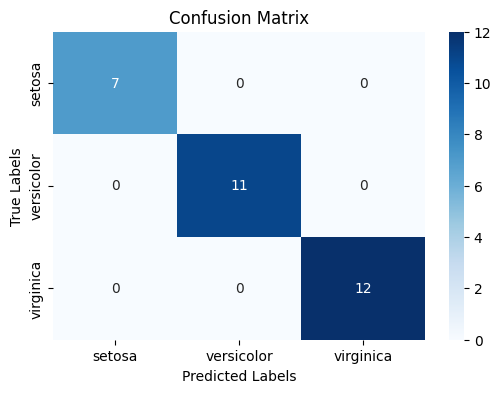

In [ ]:
print("Model Evaluation:")

# Calculate accuracy on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Calculate accuracy on test data
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

# Calculate the classification report
report = classification_report(y_test, y_pred, target_names=iris.target_names)

# Print the classification report
print("\nClassification Report:")
print(report)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# **Performing ID3 on another dataset - BREAST CANCER DATASET**

In [ ]:
# Load the Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()
X_breast_cancer = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y_breast_cancer = pd.Series(breast_cancer.target)
X_breast_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Split the Breast Cancer dataset into training and test sets
X_breast_cancer_train, X_breast_cancer_test, y_breast_cancer_train, y_breast_cancer_test = train_test_split(X_breast_cancer, y_breast_cancer, test_size=0.2, random_state=42)

# Train the ID3 model on the Breast Cancer dataset
breast_cancer_decision_tree = build_tree(X_breast_cancer_train, y_breast_cancer_train,  max_depth=4)

# Make predictions on the Breast Cancer test set
y_breast_cancer_pred = predict_all(breast_cancer_decision_tree, X_breast_cancer_test)

# Use predict_all to make predictions for the training set
y_train_breast_cancer_pred = predict_all(breast_cancer_decision_tree, X_breast_cancer_train)

Model Evaluation:
Breast Cancer TRAINING Dataset Accuracy: 91.21%
Breast Cancer TESTING Dataset Accuracy: 93.86%
Confusion Matrix:
[[ 7  0  0]
 [ 0 11  0]
 [ 0  0 12]]


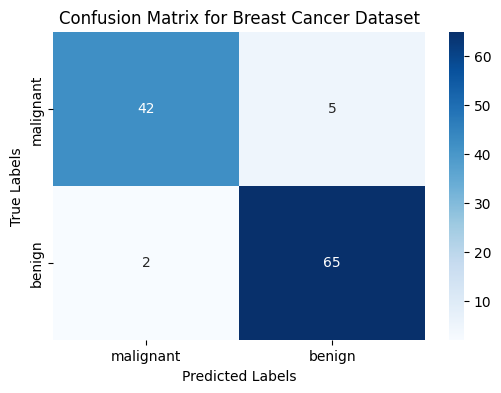

In [ ]:
# Evaluate the model
print("Model Evaluation:")
breast_cancer_train_accuracy = accuracy_score(y_breast_cancer_train, y_train_breast_cancer_pred)
print(f"Breast Cancer TRAINING Dataset Accuracy: {breast_cancer_train_accuracy * 100:.2f}%")

breast_cancer_test_accuracy = accuracy_score(y_breast_cancer_test, y_breast_cancer_pred)
print(f"Breast Cancer TESTING Dataset Accuracy: {breast_cancer_test_accuracy * 100:.2f}%")

breast_cancer_cm = confusion_matrix(y_breast_cancer_test, y_breast_cancer_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(breast_cancer_cm, annot=True, fmt="d", cmap="Blues", xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
plt.title('Confusion Matrix for Breast Cancer Dataset')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()